<a href="https://colab.research.google.com/github/droyktton/ICNPG/blob/master/Clases/Colaboratory/cupyfft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Fri May  7 19:03:21 2021       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 465.19.01    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   46C    P8     9W /  70W |      0MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

# FFT en gpu con CUPY

Sea $H_n= \sin( 2 \pi q n/N)=\frac{e^{2 \pi i q n/N}-e^{-2 \pi i q n/N}}{2 i} = \frac{-i}{2} e^{2 \pi i q n/N} + \frac{i}{2} e^{2 \pi i q (N-n)/N}$ una señal real

comparemos eso con la expresión de la transformada discreta

$H_n = \frac{1}{N} \sum_{k=0}^{N-1} h_k e^{-2 \pi i k n/N}$

Entonces las amplitudes de Fourier son $h_q=-(i/2)N$,  $h_{N-q}=(i/2)N$, $h_k=0$ ($k\neq q$, $k\neq(N-q)$)

real size = 512
transformada size = 512


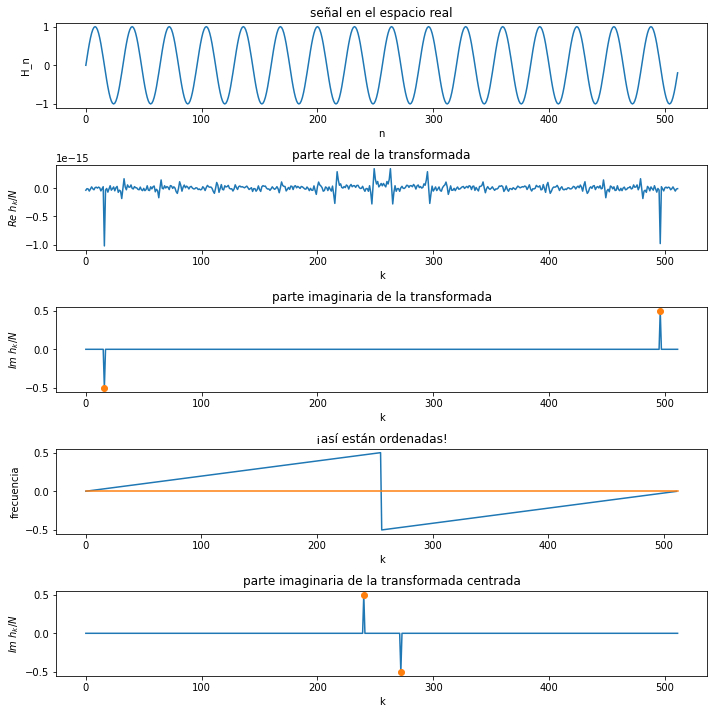

In [ ]:
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt

N=512
q=16

H = np.sin(q*np.arange(N)*2*np.pi/N)

D = cp.array(H, dtype=float)

#notar que dividimos por N las amplitudes
d_fourier = cp.fft.fft(D)/N

print("real size =", H.size)
print("transformada size =", d_fourier.size)


h_fourier = cp.asnumpy(d_fourier)
h_fourier_shifted=np.fft.fftshift(h_fourier)

fig, ax = plt.subplots(5,figsize=(10,10))

ax[0].plot(H)
ax[0].set(xlabel='n', ylabel='H_n', title='señal en el espacio real')

ax[1].plot(h_fourier.real)
ax[1].set(xlabel='k', ylabel='$Re\; h_k/N$', title='parte real de la transformada')

ax[2].plot(h_fourier.imag)
ax[2].plot([q,N-q],[-1/2,1/2],'o')
ax[2].set(xlabel='k', ylabel='$Im\; h_k/N$', title='parte imaginaria de la transformada')

freq=np.fft.fftfreq(N, d=1.0)

ax[3].plot(freq)
ax[3].plot([0,N],[0,0])
ax[3].set(xlabel='k', ylabel='frecuencia', title='¡así están ordenadas!')

ax[4].plot(h_fourier_shifted.imag)
ax[4].plot([N/2-q,N/2+q],[1/2,-1/2],'o')
ax[4].set(xlabel='k', ylabel='$Im\; h_k/N$', title='parte imaginaria de la transformada centrada')

fig.tight_layout(pad=1)

plt.show()

Usando real to complex [rfft](https://docs.cupy.dev/en/stable/reference/generated/cupy.fft.rfft.html) se economiza memoria usando que la transformada de una función real es simétrica conjugada...

real size = 512
transformada size = 257


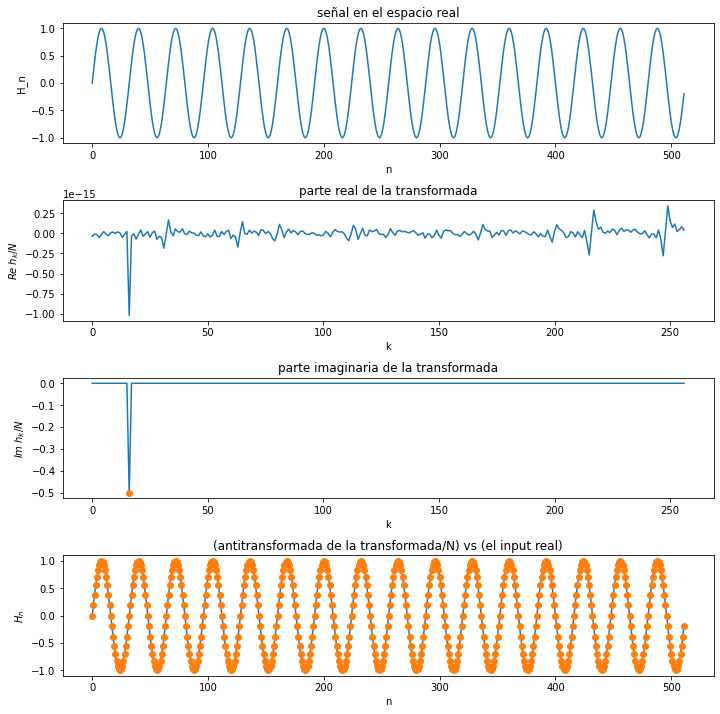

In [ ]:
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

N=512
q=16

H = np.sin(q*np.arange(N)*2*np.pi/N)

D = cp.array(H, dtype=float)

d_fourier = cp.fft.rfft(D)

print("real size =", H.size)
print("transformada size =", d_fourier.size)

h_fourier = cp.asnumpy(d_fourier)
h_fourier_shifted=cp.fft.fftshift(h_fourier)

fig, ax = plt.subplots(4,figsize=(10,10))

ax[0].plot(H)
ax[0].set(xlabel='n', ylabel='H_n', title='señal en el espacio real')

#notar que dividimos por N las amplitudes
ax[1].plot(h_fourier.real/N)
ax[1].set(xlabel='k', ylabel='$Re\; h_k/N$', title='parte real de la transformada')

ax[2].plot(h_fourier.imag/N)
ax[2].plot([q],[-1/2],'o')
ax[2].set(xlabel='k', ylabel='$Im\; h_k/N$', title='parte imaginaria de la transformada')

#notar que dividimos por N la antitransformada
#porque la ifft(fft) es N*Identidad
H_anti = np.fft.irfft(h_fourier)
ax[3].plot(H_anti)
ax[3].plot(H,'o')
ax[3].set(xlabel='n', ylabel='$H_n$', title='(antitransformada de la transformada/N) vs (el input real)')


fig.tight_layout(pad=1)

plt.show()

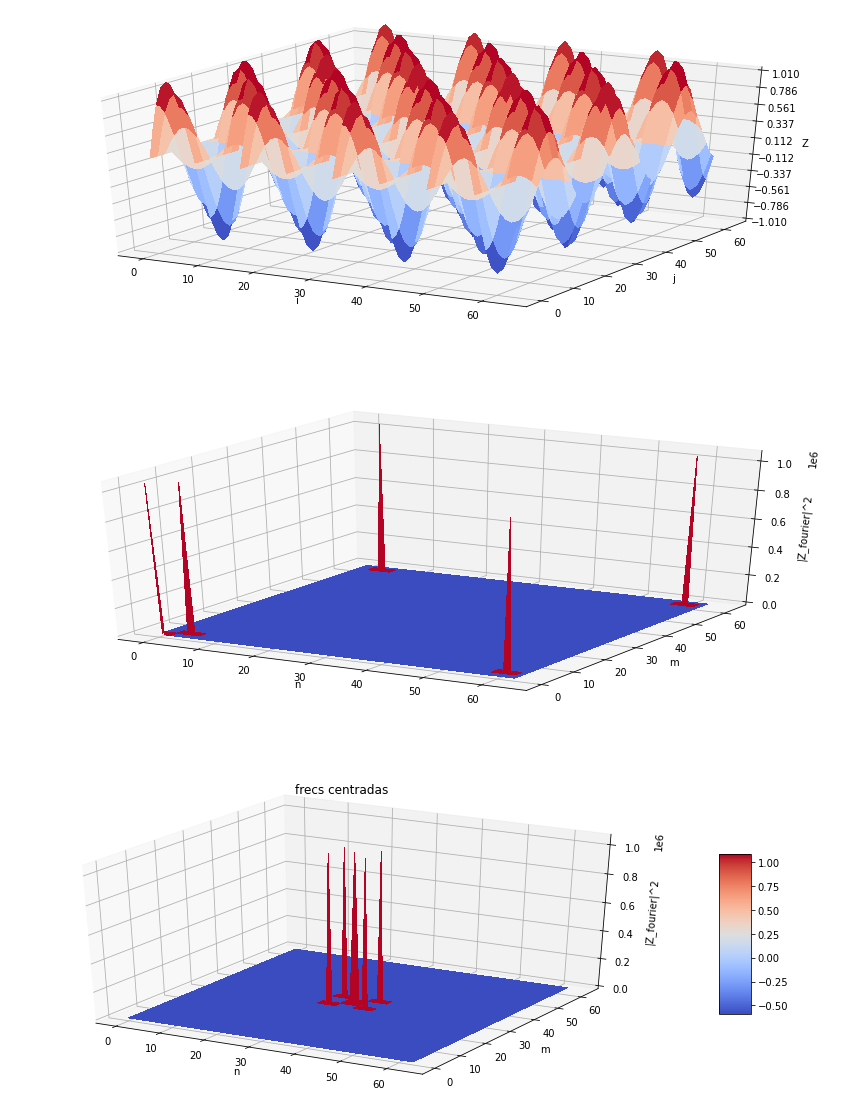

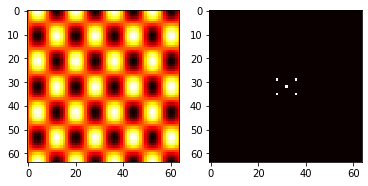

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import numpy as np
import cupy as cp

fig, ax = plt.subplots(3,subplot_kw={"projection": "3d"},figsize=(15,20))

N=64
qx=4
qy=3

# Make data.
X = np.arange(0, N, 1)
Y = np.arange(0, N, 1)
X, Y = np.meshgrid(X, Y)
Z = 0.25+np.sin(2*np.pi*qx*X/N)*np.cos(2*np.pi*qy*Y/N) #+0.5*np.sin(2*np.pi*0.7*X +2*np.pi*0.7*Y)
#Z = 0.25+np.sin(2*np.pi*qx*(X+Y)/N)

# Plot the surface.
surf = ax[0].plot_surface(X, Y, Z, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax[0].set(xlabel='i', ylabel='j', zlabel='Z')

# Customize the z axis.
ax[0].set_zlim(-1.01, 1.01)
ax[0].zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
#ax.zaxis.set_major_formatter('{x:.02f}')

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)


#Z en host -> d_Z en device
d_Z=cp.array(Z)

# transformada en gpu
d_Z_fourier=cp.fft.fft2(d_Z)

# modulo cuadrado de la transformada en gpu
d_W = cp.abs(d_Z_fourier)**2 

# modulo cuadrado a host
W = cp.asnumpy(d_W)

# Plot the surface.
surf = ax[1].plot_surface(X, Y, W, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax[1].set(xlabel='n', ylabel='m', zlabel='|Z_fourier|^2')


# Plot the surface.
surf = ax[2].plot_surface(X, Y, np.fft.fftshift(W), cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax[2].set(xlabel='n', ylabel='m', zlabel='|Z_fourier|^2', title = 'frecs centradas')

plt.show()

fig, bx = plt.subplots(1,2)

bx[0].imshow(Z, cmap='hot', interpolation='nearest')
bx[1].imshow(np.fft.fftshift(W), cmap='hot', interpolation='nearest')
plt.show()

